### This script is intended to do the following data flow:
[A] Firebase Storage (financials.json)
        ↓
[B] Python script (server / notebook / job)
        ↓
[C] Parsed JSON → flows
        ↓
[D] Sankey diagram (Plotly / Matplotlib)

## Create function to load financials Json

In [1]:
# [A] Firebase Storage (%.json)
import json
from google.cloud.storage import Client

def load_financials_json(
    *,
    storage_client: Client,
    bucket_name: str,
    object_path: str,
) -> dict:
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(object_path)

    if not blob.exists():
        raise FileNotFoundError(
            f"Financials JSON not found: {bucket_name}/{object_path}"
        )

    text = blob.download_as_text()
    return json.loads(text)


## Initialise Google Storage client

In [3]:
import json
import os
from dotenv import load_dotenv
from google.cloud import firestore, storage

# Load env vars (local dev only; safe to keep for API)
load_dotenv()

SERVICE_ACCOUNT_PATH = os.getenv("FIREBASE_SERVICE_ACCOUNT_JSON")
BUCKET_NAME = os.getenv("GCP_STORAGE_BUCKET")

if not BUCKET_NAME:
    raise RuntimeError("Missing GCP_STORAGE_BUCKET in environment")

# --- Client initialization ---
# Local dev: use service account JSON
# Production (Cloud Run / Functions): use default credentials
if SERVICE_ACCOUNT_PATH:
    db = firestore.Client.from_service_account_json(SERVICE_ACCOUNT_PATH)
    storage_client = storage.Client.from_service_account_json(SERVICE_ACCOUNT_PATH)
else:
    db = firestore.Client()
    storage_client = storage.Client()

print(SERVICE_ACCOUNT_PATH)
print(BUCKET_NAME)
print(db)

C:/Users/hongn/idealy_new/idealy/backend/funwai-resume-firebase-adminsdk-fbsvc-a956eb6362.json
funwai-resume.firebasestorage.app


In [5]:
ticker_input = 'AAPL'
ticker_year = 2025

print(BUCKET_NAME)

# load cashFlow statement
data_cashFlow = load_financials_json(
    storage_client=storage_client,
    bucket_name=BUCKET_NAME,
    object_path="filings/"+ticker_input+"/"+str(ticker_year)+"/statements/cashFlow.json"
)

# load income statement
data_incomeStatement = load_financials_json(
    storage_client=storage_client,
    bucket_name=BUCKET_NAME,
    object_path="filings/"+ticker_input+"/"+str(ticker_year)+"/statements/incomeStatement.json"
)


funwai-resume.firebasestorage.app


In [7]:
print(data_cashFlow)
data_cashFlow.keys()

{'Net profit (or loss if negative)': 112010000000.0, 'Depreciation (wear & tear on assets)': 11698000000.0, 'stock_comp': 12863000000.0, 'change_ar': 6682000000.0, 'change_inventory': None, 'change_ap': 902000000.0, 'Cash from day-to-day business (Operating Cashflow)': 111482000000.0, 'Buying equipment/buildings (Capital Expenditure)': 12715000000.0, 'acquisitions': None, 'asset_sales': None, 'investments_purchase': None, 'investments_maturity': None, 'Cash from investments (Buying/Selling assets)': 15195000000.0, 'Money raised from issuing new shares': None, 'Money spent buying back shares of company': 90711000000.0, 'Borrowed money (New loans or bonds)': 4481000000.0, 'Loan repayments': 10932000000.0, 'Dividends paid to shareholders': 15421000000.0, 'Cash from investors and loans (Financing activities)': -120686000000.0, 'Change in cash during the period': None, 'Cash at the beginning of the period': None, 'Cash remaining at the end of the period': 35934000000.0}


dict_keys(['Net profit (or loss if negative)', 'Depreciation (wear & tear on assets)', 'stock_comp', 'change_ar', 'change_inventory', 'change_ap', 'Cash from day-to-day business (Operating Cashflow)', 'Buying equipment/buildings (Capital Expenditure)', 'acquisitions', 'asset_sales', 'investments_purchase', 'investments_maturity', 'Cash from investments (Buying/Selling assets)', 'Money raised from issuing new shares', 'Money spent buying back shares of company', 'Borrowed money (New loans or bonds)', 'Loan repayments', 'Dividends paid to shareholders', 'Cash from investors and loans (Financing activities)', 'Change in cash during the period', 'Cash at the beginning of the period', 'Cash remaining at the end of the period'])

In [9]:
print(data_incomeStatement) # currently income statement is what I use to draw Sankey diagrams
data_incomeStatement.keys()

{'revenue': {'Total Revenue': 307003000000.0, 'Advertising Revenue': None, 'Interest Income': None, 'Other Income': None}, 'expenses': {'Cost of Revenue': None, 'Research & Development': 34550000000.0, 'Sales & Marketing': 10174000000.0, 'General & Administrative': 8077000000.0, 'Operating Expenses (Total)': 62151000000.0, 'Interest Expense': None, 'Income Tax Expense': 20719000000.0}, 'profit': {'Gross Profit': 195201000000.0, 'Operating Income': 133050000000.0, 'Income Before Tax': 132729000000.0, 'Net Income': 112010000000.0}, 'shares': {'Earnings per Share (Basic)': 7.49, 'Earnings per Share (Diluted)': 7.46, 'Weighted Average Shares Outstanding (Basic)': 14948500000.0, 'Weighted Average Shares Outstanding (Diluted)': 15004697000.0}}


dict_keys(['revenue', 'expenses', 'profit', 'shares'])

## Convert income statement into Sankey diagram

In [21]:
import plotly.graph_objects as go

def format_money(v):
    if v >= 1_000_000_000:
        return f"${v/1_000_000_000:.0f}B"
    elif v >= 1_000_000:
        return f"${v/1_000_000:.0f}M"
    else:
        return f"${v:.0f}"

def revenue_to_expense_sankey(data):

    revenue = data['revenue']['Total Revenue']
    gross_profit = data['profit']['Gross Profit']
    net_income = data['profit']['Net Income']

    rd = data['expenses']['Research & Development'] or 0
    sm = data['expenses']['Sales & Marketing'] or 0
    ga = data['expenses']['General & Administrative'] or 0
    tax = data['expenses']['Income Tax Expense'] or 0

    cost_of_revenue = revenue - gross_profit

    labels = [
        f"Total Revenue\n{format_money(revenue)}",
        f"Cost of Revenue\n{format_money(cost_of_revenue)}",
        f"R&D\n{format_money(rd)}",
        f"Sales & Marketing\n{format_money(sm)}",
        f"G&A\n{format_money(ga)}",
        f"Income Tax\n{format_money(tax)}",
        f"Net Income\n{format_money(net_income)}"
    ]

    values = [
        cost_of_revenue,
        rd,
        sm,
        ga,
        tax,
        net_income
    ]

    sources = [0] * len(values)
    targets = [1, 2, 3, 4, 5, 6]

    node_colors = [
        "#4C4C4C",  # revenue
        "#D62728",
        "#D62728",
        "#D62728",
        "#D62728",
        "#D62728",
        "#2CA02C"   # net income
    ]

    link_colors = [
        "#F28E8E" if i < 5 else "#8FD19E"
        for i in range(len(values))
    ]

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=30,
            thickness=25,
            line=dict(color="black", width=0.3),
            label=labels,
            color=node_colors,
            x=[0.05] + [0.95]*6,
            y=[0.5, 0.05, 0.2, 0.35, 0.5, 0.65, 0.85]
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
            label=[format_money(v) for v in values]
        )
    ))

    fig.update_layout(
        title="Revenue Allocation",
        font_size=13,
        height=700
    )

    fig.show()

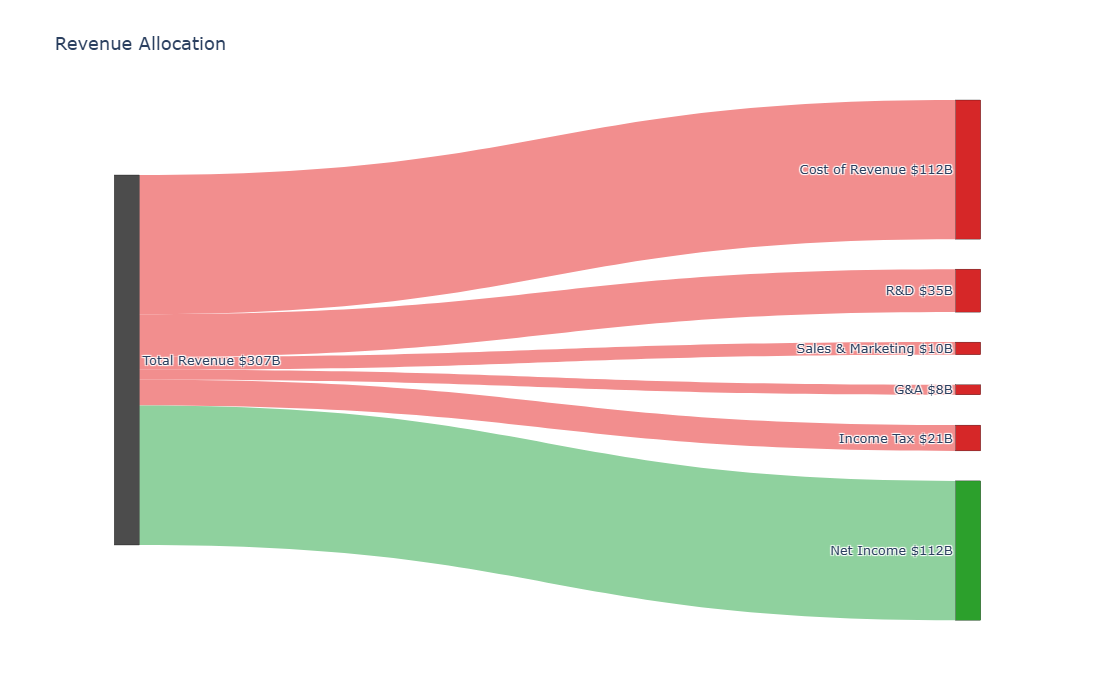

In [23]:
revenue_to_expense_sankey(data_incomeStatement)